In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [2]:
display(df.head())
df.info()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# 数値型に変換
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")
# 目的変数の処理
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})
# カテゴリ変数の処理
df = pd.get_dummies(df,drop_first=True)

display(df.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [4]:
# データの分割
X = df.drop("Churn",axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

選ばれた最適パラメータ: {'max_depth': 5, 'min_samples_leaf': 50}
Accuracy (正解率): 0.8077
ROC-AUC スコア   : 0.8480


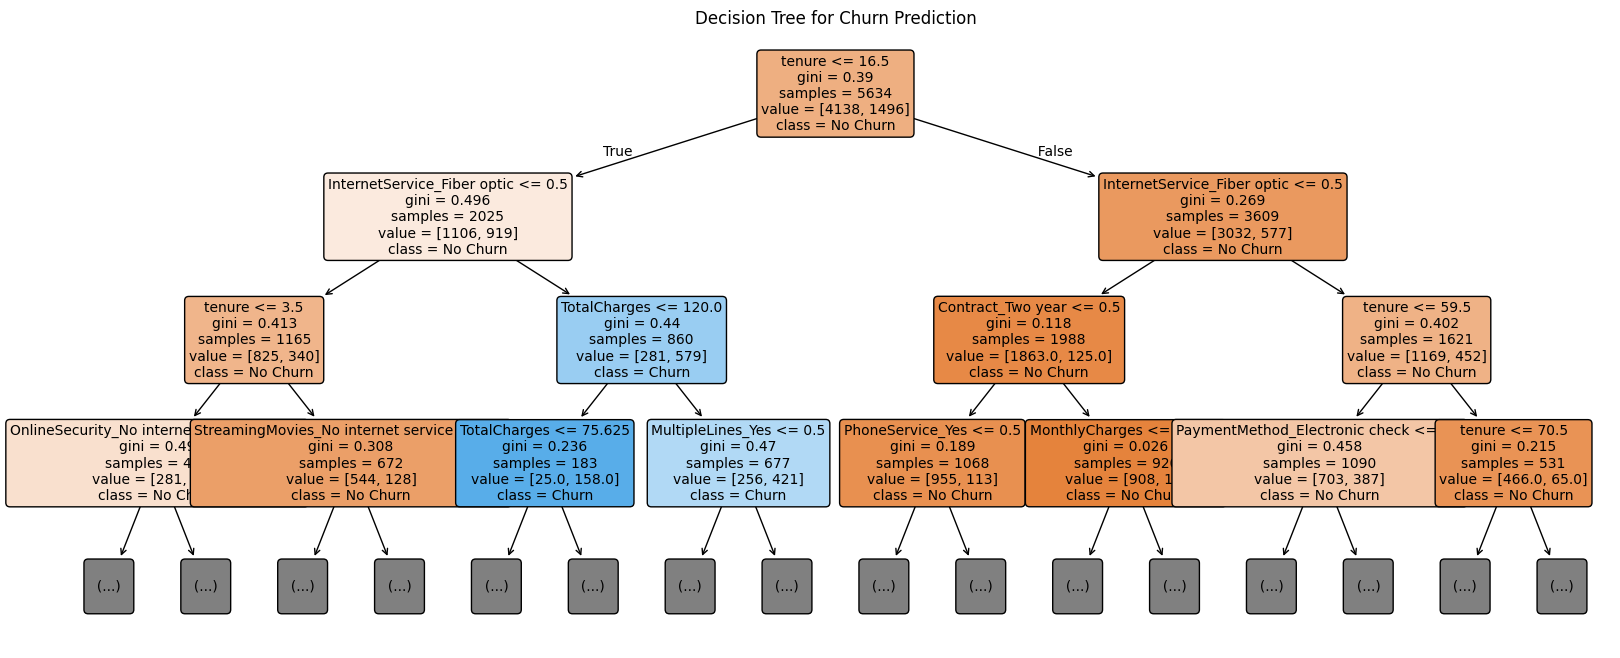

In [5]:
# 決定木
dt = DecisionTreeClassifier(random_state=42)
params = {
    "max_depth":[3,4,5,7,10],
    "min_samples_leaf":[1,5,10,20,30,50]
}

grid_search = GridSearchCV(dt,params,cv=5,scoring="roc_auc",n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

print(f"選ばれた最適パラメータ: {grid_search.best_params_}")
print(f"Accuracy (正解率): {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC スコア   : {roc_auc_score(y_test, y_pred_proba):.4f}")

plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=X.columns, class_names=['No Churn', 'Churn'],
          filled=True, rounded=True, max_depth=3, fontsize=10)
plt.title("Decision Tree for Churn Prediction")
plt.show()

選ばれた最適パラメータ: {'max_depth': 7, 'n_estimators': 100}
Accuracy (正解率): 0.8048
ROC-AUC スコア   : 0.8642


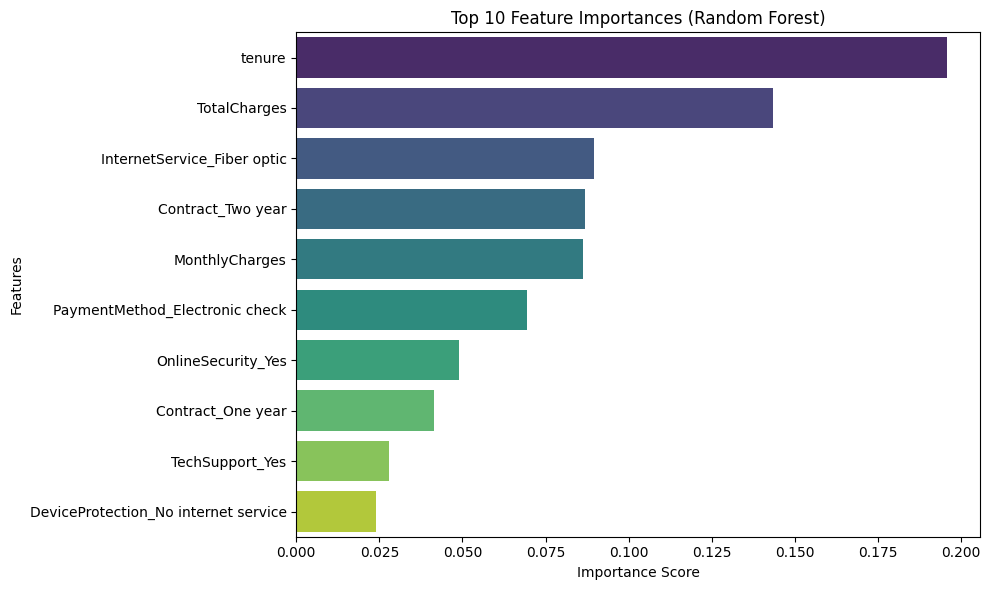

In [6]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# ランダムフォレスト
rf = RandomForestClassifier(random_state=42,n_jobs=-1)
rf_params = {
    "n_estimators":[50,100,150,200],
    "max_depth":[5,7,10,"None"]
}
rf_grid = GridSearchCV(rf,rf_params,cv=5,scoring="roc_auc")
rf_grid.fit(X_train,y_train)

# 選ばれたモデル
best_rf = rf_grid.best_estimator_

# 評価
rf_y_pred = best_rf.predict(X_test)
rf_y_pred_proba = best_rf.predict_proba(X_test)[:,1]

print(f"選ばれた最適パラメータ: {rf_grid.best_params_}")
print(f"Accuracy (正解率): {accuracy_score(y_test, rf_y_pred):.4f}")
print(f"ROC-AUC スコア   : {roc_auc_score(y_test, rf_y_pred_proba):.4f}")

# 特徴量の重要度
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='viridis')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [7]:
print(rf_importance)

                                 Feature  Importance
1                                 tenure    0.195903
3                           TotalCharges    0.143388
10           InternetService_Fiber optic    0.089524
25                     Contract_Two year    0.086963
2                         MonthlyCharges    0.086318
28        PaymentMethod_Electronic check    0.069399
13                    OnlineSecurity_Yes    0.049039
24                     Contract_One year    0.041284
19                       TechSupport_Yes    0.027779
16  DeviceProtection_No internet service    0.023978


[LightGBM] [Warning] Unknown parameter: lerning_rate
[LightGBM] [Warning] Unknown parameter: vervose
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: lerning_rate
[LightGBM] [Warning] Unknown parameter: vervose
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000642 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 637
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

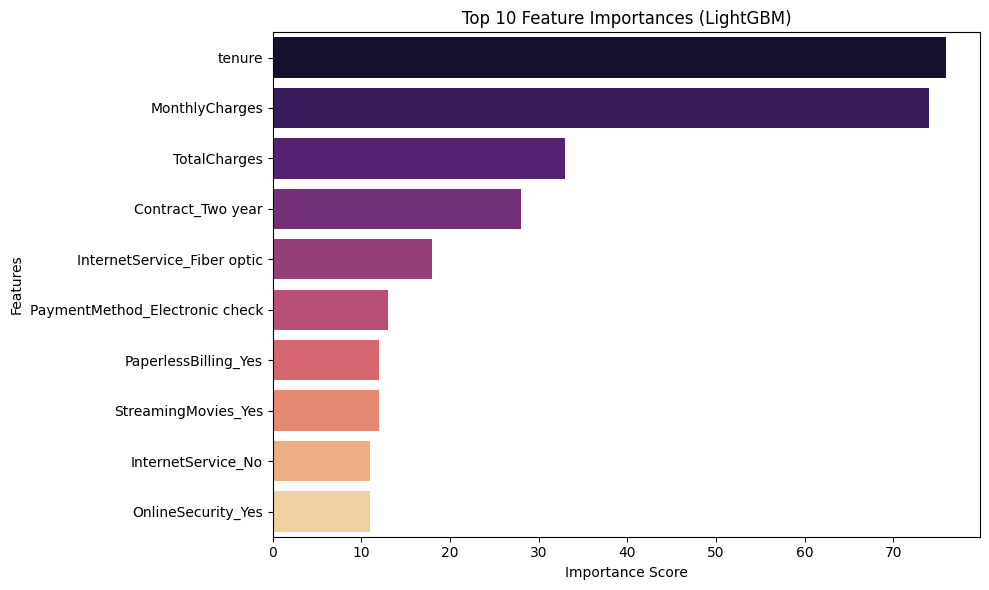

In [8]:
import lightgbm as lgb

# 勾配ブースティング
lgbm = lgb.LGBMClassifier(random_state=42,vervose=-1)
lgbm_params = {
    "lerning_rate":[0.005,0.01,0.05,0.1,0.2],
    "n_estimators":[30,50,100,150,200],
    "max_depth":[2,3,5,7]
}
lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=5, scoring='roc_auc', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

# 選ばれたモデル
best_lgbm = lgbm_grid.best_estimator_

# 評価
lgbm_y_pred = best_lgbm.predict(X_test)
lgbm_y_pred_proba = best_lgbm.predict_proba(X_test)[:, 1]

print(f"選ばれた最適パラメータ: {lgbm_grid.best_params_}")
print(f"Accuracy (正解率): {accuracy_score(y_test, lgbm_y_pred):.4f}")
print(f"ROC-AUC スコア   : {roc_auc_score(y_test, lgbm_y_pred_proba):.4f}")

# 特徴量の重要度
lgbm_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=lgbm_importance, palette='magma')
plt.title("Top 10 Feature Importances (LightGBM)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

# ランダムフォレストで重要な特徴量を選別
selector_rf = RandomForestClassifier(random_state=42, n_estimators=100)
selector_rf.fit(X_train, y_train)
importances = pd.Series(selector_rf.feature_importances_, index=X_train.columns)
top10_features = importances.nlargest(10).index.tolist()
print(f"選ばれたトップ10変数:\n{top10_features}")

X_train_selected = X_train[top10_features]
X_test_selected = X_test[top10_features]


imputer = SimpleImputer(strategy='mean')
X_train_selected = pd.DataFrame(imputer.fit_transform(X_train_selected), columns=X_train_selected.columns, index=X_train_selected.index)
X_test_selected = pd.DataFrame(imputer.transform(X_test_selected), columns=X_test_selected.columns, index=X_test_selected.index)

# 標準化
scaler = StandardScaler()
X_train_scaled_sel = scaler.fit_transform(X_train_selected)
X_test_scaled_sel = scaler.transform(X_test_selected)

# パラメーター
models_selected = {
    "SVM (厳選特徴量版)": {
        "model": SVC(probability=True, random_state=42),
        "params": {"C": [0.1, 0.5, 1.0], "kernel": ['linear', 'rbf']}
    },
    "k-NN (厳選特徴量版)": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [5, 10, 30, 50]}
    }
}

results_selected = [] # 変数名を resutls_selected から results_selected に修正

# SVMとK近傍法
for name, mp in models_selected.items():
    clf = GridSearchCV(mp["model"], mp["params"], cv=5, scoring='roc_auc', n_jobs=-1)

    clf.fit(X_train_scaled_sel, y_train)

    y_pred = clf.predict(X_test_scaled_sel)
    y_pred_proba = clf.predict_proba(X_test_scaled_sel)[:, 1]

    results_selected.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
        "Best Params": str(clf.best_params_)
    })

display(pd.DataFrame(results_selected).set_index("Model"))

選ばれたトップ10変数:
['TotalCharges', 'tenure', 'MonthlyCharges', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'OnlineSecurity_Yes', 'gender_Male', 'PaperlessBilling_Yes', 'Partner_Yes']


,Accuracy,ROC-AUC,Best Params
Model,,,
SVM (厳選特徴量版),0.804116,0.838605,"{'C': 0.1, 'kernel': 'linear'}"
k-NN (厳選特徴量版),0.792051,0.843618,{'n_neighbors': 50}


In [13]:
print(pd.DataFrame(results_selected).set_index("Model"))

               Accuracy   ROC-AUC                     Best Params
Model                                                            
SVM (厳選特徴量版)   0.804116  0.838605  {'C': 0.1, 'kernel': 'linear'}
k-NN (厳選特徴量版)  0.792051  0.843618             {'n_neighbors': 50}
